# **Stock Price Anomaly Detection**

In [151]:
# Installing yfinance
# !pip install yfinance
# !pip install "jupyterlab>=3" "ipywidgets>=7.6" anywidget

**Importing Libraries and Modules**

In [152]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
import seaborn as sns
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'notebook_connected'

## **Getting and Importing of Data**

In [153]:
ticker, start_date, end_date = "CVX", "2022-01-01", "2026-04-20"
df = yf.download(ticker, start=start_date, end=end_date, multi_level_index=False)
df

[*********************100%***********************]  1 of 1 completed


,Close,High,Low,Open,Volume
Date,,,,,
2022-01-03,100.499321,100.861678,98.839219,98.948766,10717700
2022-01-04,102.327957,102.791440,100.836397,101.080772,16413100
2022-01-05,102.993668,104.358823,102.867263,103.010519,15487100
2022-01-06,103.870064,104.763314,102.504902,104.173433,13318500
2022-01-07,105.361626,105.791400,103.608827,104.114447,14164600
...,...,...,...,...,...
2026-04-13,191.779999,192.610001,189.720001,191.449997,12000200
2026-04-14,187.020004,189.169998,184.600006,188.600006,12111000
2026-04-15,184.910004,187.240005,184.039993,186.360001,8661600


### **Minor Data Wrangling**

In [154]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1076 entries, 2022-01-03 to 2026-04-17
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1076 non-null   float64
 1   High    1076 non-null   float64
 2   Low     1076 non-null   float64
 3   Open    1076 non-null   float64
 4   Volume  1076 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 50.4 KB


### **Explore (Data Visualization)**

In [155]:
fig = go.Figure(data=[go.Candlestick(x=df.index,
                open=df['Open'],
                high=df['High'],
                low=df['Low'],
                close=df['Close'])])
fig.show()

## Adding Moving Averages

In [156]:
df['21_day_ma'] = df['Close'].rolling(21).mean() #21 days moving average 
df['21_day_ma'].fillna(0)

Date
2022-01-03      0.000000
2022-01-04      0.000000
2022-01-05      0.000000
2022-01-06      0.000000
2022-01-07      0.000000
                 ...    
2026-04-13    200.355714
2026-04-14    199.889047
2026-04-15    199.320952
2026-04-16    198.853333
2026-04-17    198.157142
Name: 21_day_ma, Length: 1076, dtype: float64

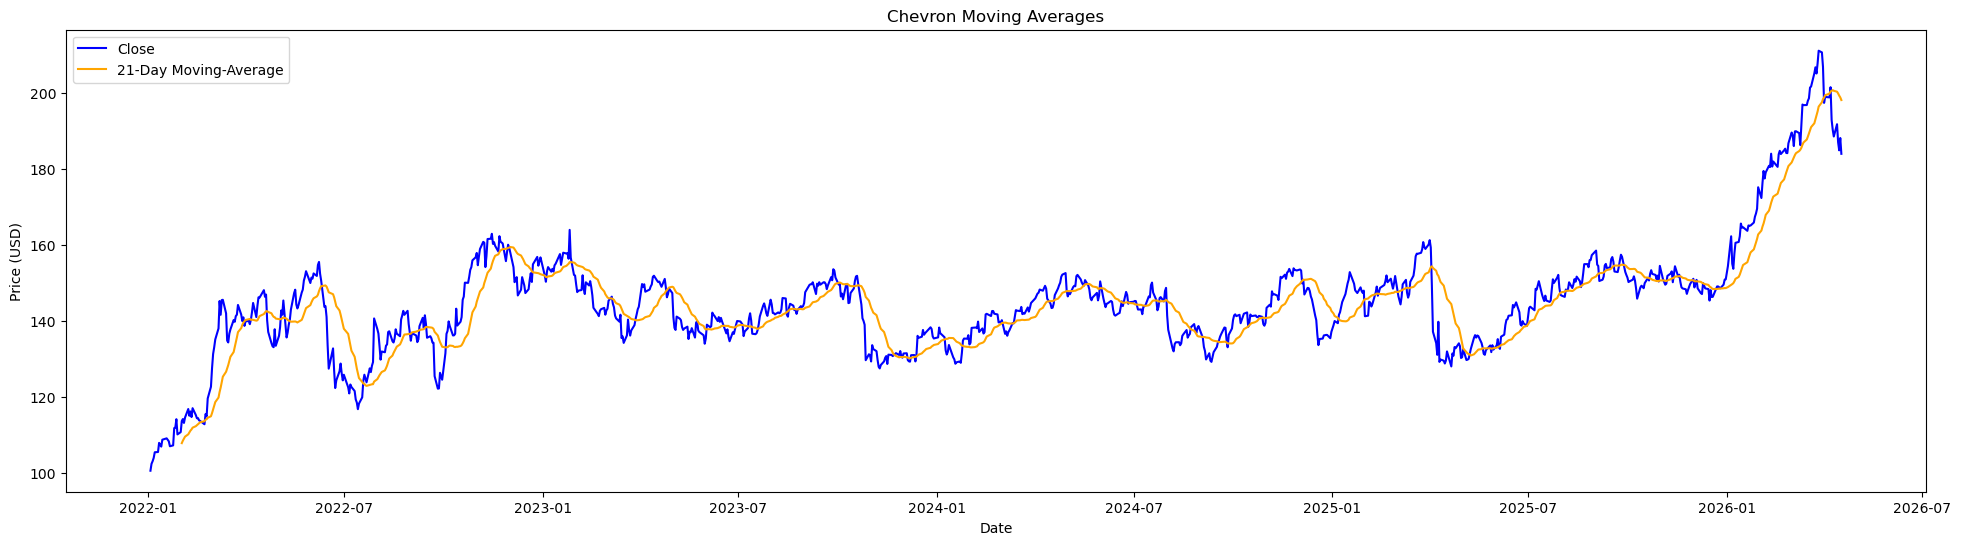

In [168]:
plt.figure(figsize=(24,6))
plt.plot(df['Close'], label='Close', alpha=1, color='blue')
plt.plot(df['21_day_ma'], label='21-Day Moving-Average', color='orange')
plt.title("Chevron Moving Averages")
plt.xlabel("Date") 
plt.ylabel("Price (USD)")
plt.legend()
plt.show();

## **Anomaly Detection using Isolation Forest**

In [165]:
# Feature selection
features = ['Close', 'High', 'Low', 'Open', 'Volume']
X = df[features]

# Isolation Forest Instanciation
Iso_forest_model = IsolationForest(contamination=0.02, random_state=42)

# fitting the model
Iso_forest_model.fit(X)

# Prediction/Detection
df['Iso_Anomaly'] = Iso_forest_model.predict(X)
Detected_Anomaly = df[df['Iso_Anomaly']== -1]

In [166]:
df["Iso_Anomaly"].unique()

array([-1,  1])

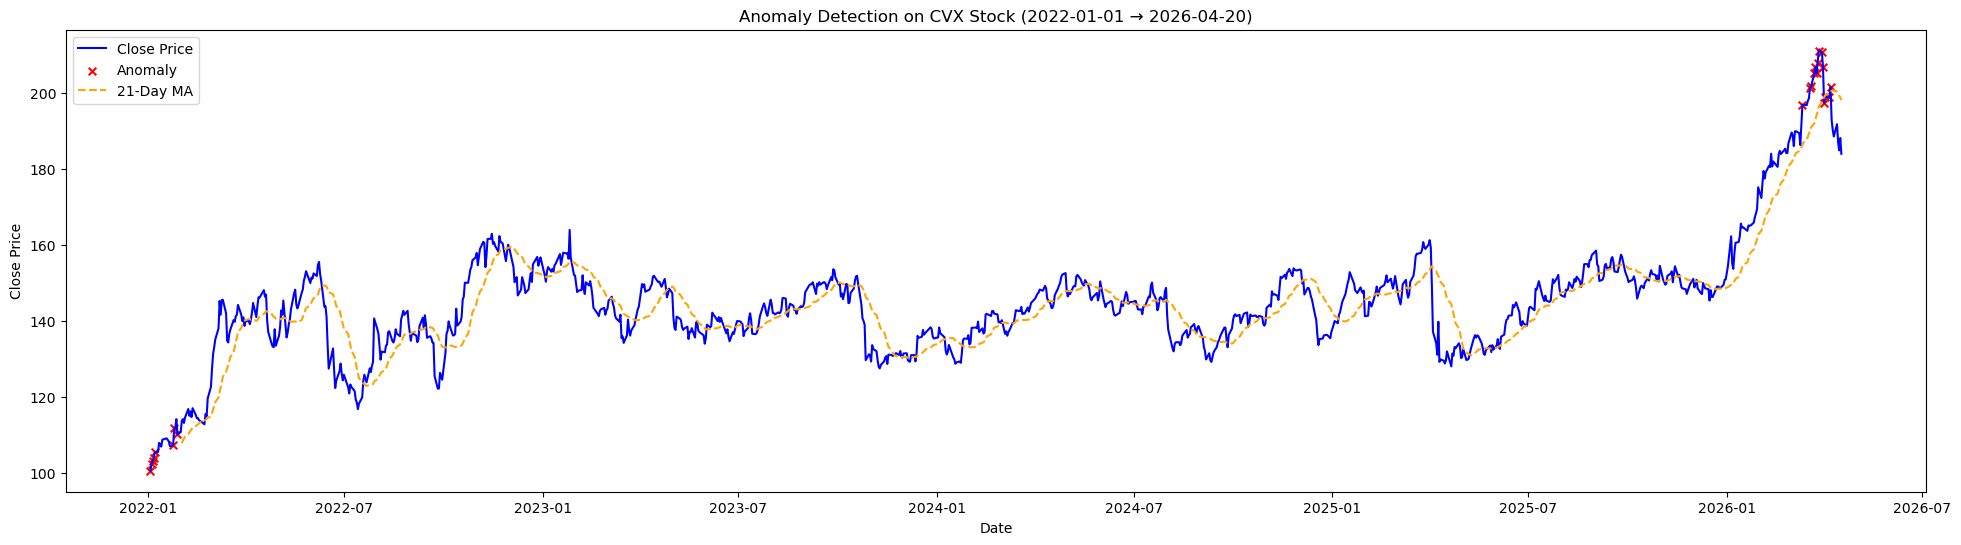

In [167]:
plt.figure(figsize=(24,6))
plt.plot(df.index, df['Close'], label="Close Price", color="blue")
plt.scatter(Detected_Anomaly.index, Detected_Anomaly['Close'], color="red", marker="x", s=30, label="Anomaly")
plt.plot(df.index, df['21_day_ma'], label="21-Day MA", color="orange", linestyle="--")
plt.title(f"Anomaly Detection on {ticker} Stock ({start_date} → {end_date})")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.legend()

    # Show chart + anomalies table + 21 Days Moving Averages
plt.show()

In [135]:
df

,Close,High,Low,Open,Volume,21_day_ma,Iso_Anomaly
Date,,,,,,,
2022-01-03,100.499321,100.861678,98.839219,98.948766,10717700,NaN,-1
2022-01-04,102.327957,102.791440,100.836397,101.080772,16413100,NaN,-1
2022-01-05,102.993668,104.358823,102.867263,103.010519,15487100,NaN,-1
2022-01-06,103.870064,104.763314,102.504902,104.173433,13318500,NaN,-1
2022-01-07,105.361626,105.791400,103.608827,104.114447,14164600,NaN,-1
...,...,...,...,...,...,...,...
2026-04-13,191.779999,192.610001,189.720001,191.449997,12000200,200.355714,1
2026-04-14,187.020004,189.169998,184.600006,188.600006,12111000,199.889047,1
2026-04-15,184.910004,187.240005,184.039993,186.360001,8661600,199.320952,1


## Anomalies Detected

In [21]:
Detected_Anomaly

Price,Close,High,Low,Open,Volume,21_day_ma,Iso_Anomaly
Ticker,CVX,CVX,CVX,CVX,CVX,,
Date,,,,,,,
2020-03-09,63.147400,68.893057,62.622934,64.368551,30595500,80.170166,-1
2020-03-12,59.695309,61.159116,57.033833,60.454613,25768200,77.118855,-1
2020-03-13,65.300064,65.362688,58.012322,62.607282,23497500,76.100279,-1
2020-03-17,55.335186,57.127768,51.264692,55.108177,22684200,73.115997,-1
2020-03-18,43.092400,51.843957,42.716662,51.828298,24947300,71.058759,-1
2020-03-19,44.924126,45.785193,40.391790,43.256789,29871000,69.070108,-1
2020-03-20,46.489697,47.476009,44.117854,46.599286,26960400,67.190675,-1
2020-03-23,42.442692,46.497527,41.464209,45.605148,23764000,65.148348,-1
